<a href="https://colab.research.google.com/github/Hyon2-park/test/blob/main/%EA%B5%AC%EB%A7%A4%EB%82%B4%EC%97%AD%20%EB%B6%84%EC%84%9D_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 구글 코랩에 한글 폰트 설치
!apt-get update -qq
!apt-get install -qq -y fonts-nanum
# 한글 폰트 설정
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 117528 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
df=pd.read_csv('/content/구매내역정보.csv', encoding='cp949')
df

,ID,거래식별ID,점포ID,거래일자,거래시간대,상품대분류명,상품중분류명,구매수량,구매금액
0,B000001,Z000403,B,20140704,21,청과,감귤수박국산기타,1,12900
1,B000001,Z000677,B,20140707,14,낙농,우유,2,1700
2,B000001,Z000677,B,20140707,14,면과자,빵,1,1800
3,B000001,Z001259,B,20140714,17,음주류,주류,1,11200
4,B000001,Z001364,B,20140715,18,낙농,발효유,1,2200
...,...,...,...,...,...,...,...,...,...
55828,B001500,Z016472,A,20140830,16,야채,두채류,1,2290
55829,B001500,Z019236,A,20140920,20,음주류,주류,1,1300
55830,B001500,Z019741,A,20140923,13,낙농,발효유,1,1700
55831,B001500,Z020273,A,20140926,20,야채,계란류,1,4990


In [36]:
df['단가'] = df['구매금액']/df['구매수량']
df

,ID,거래식별ID,점포ID,거래일자,거래시간대,상품대분류명,상품중분류명,구매수량,구매금액,단가
0,B000001,Z000403,B,20140704,21,청과,감귤수박국산기타,1,12900,12900.0
1,B000001,Z000677,B,20140707,14,낙농,우유,2,1700,850.0
2,B000001,Z000677,B,20140707,14,면과자,빵,1,1800,1800.0
3,B000001,Z001259,B,20140714,17,음주류,주류,1,11200,11200.0
4,B000001,Z001364,B,20140715,18,낙농,발효유,1,2200,2200.0
...,...,...,...,...,...,...,...,...,...,...
55828,B001500,Z016472,A,20140830,16,야채,두채류,1,2290,2290.0
55829,B001500,Z019236,A,20140920,20,음주류,주류,1,1300,1300.0
55830,B001500,Z019741,A,20140923,13,낙농,발효유,1,1700,1700.0
55831,B001500,Z020273,A,20140926,20,야채,계란류,1,4990,4990.0


우유 단가가 가장 높고 구매 수량이 3위를 차지 했기 때문에 1위 매출을 차지한다.
음료는 구매수량이 가장 높으며 단가 역시 5위에 해당하기 때문에 상위 2번째 매출 품목에 해당되는 것으로 판단된다.

Text(0, 0.5, '매출액')

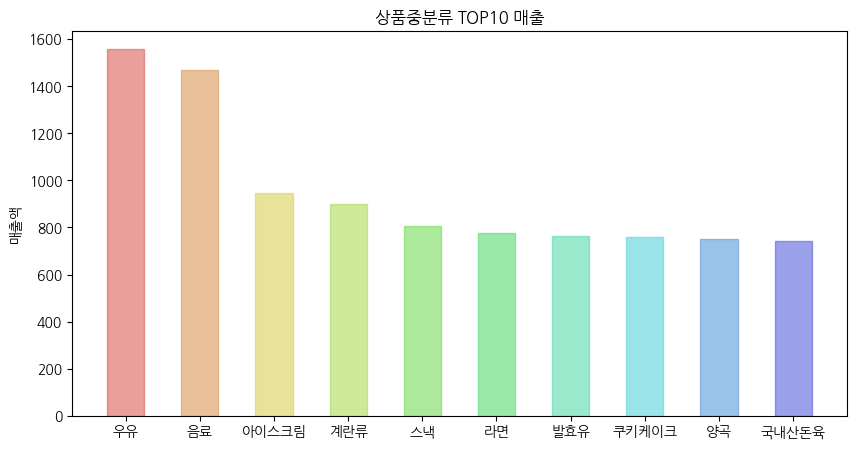

In [62]:
plt.figure(figsize=(10,5))
colors = sns.color_palette('hls',len(sales1.values)) ## 색상 지정
sales2_10k = sales2 / 10000

plt.bar(sales2_10k.index,sales2_10k.values,color=colors,edgecolor=colors,alpha=0.6,width=0.5)
plt.title('상품중분류 TOP10 매출')
plt.ylabel('매출액')


In [42]:
df.groupby(['상품대분류명','상품중분류명'])['단가'].sum().sort_values(ascending=False)/100000


,,단가
상품대분류명,상품중분류명,
낙농,우유,131.724667
야채,계란류,87.525603
곡물,양곡,74.799300
축산,국내산돈육,64.982321
음주류,음료,64.840698
...,...,...
델리카,식사류,1.469850
수산,해물류,1.467770
축산,기타축산,1.454400


In [4]:
sales1 = df.groupby('상품대분류명')['구매금액'].sum().sort_values(ascending=False)
sales1

,구매금액
상품대분류명,
야채,29999380
면과자,29963230
낙농,29282690
청과,28752101
축산,23390374
일상용품,19525440
일반식품,18235970
음주류,18171620
냉장,17824010


In [5]:
sales2= df.groupby('상품중분류명')['구매금액'].sum().sort_values(ascending=False).head(10)
sales2.

,구매금액
상품중분류명,
우유,15567970
음료,14668140
아이스크림,9451150
계란류,9008800
스낵,8067350
라면,7770060
발효유,7641720
쿠키케이크,7611390
양곡,7521820


In [45]:
df.groupby(['상품대분류명','상품중분류명'])['구매수량'].sum().sort_values(ascending=False).to_csv('제품별 구매수량.csv')

<BarContainer object of 14 artists>

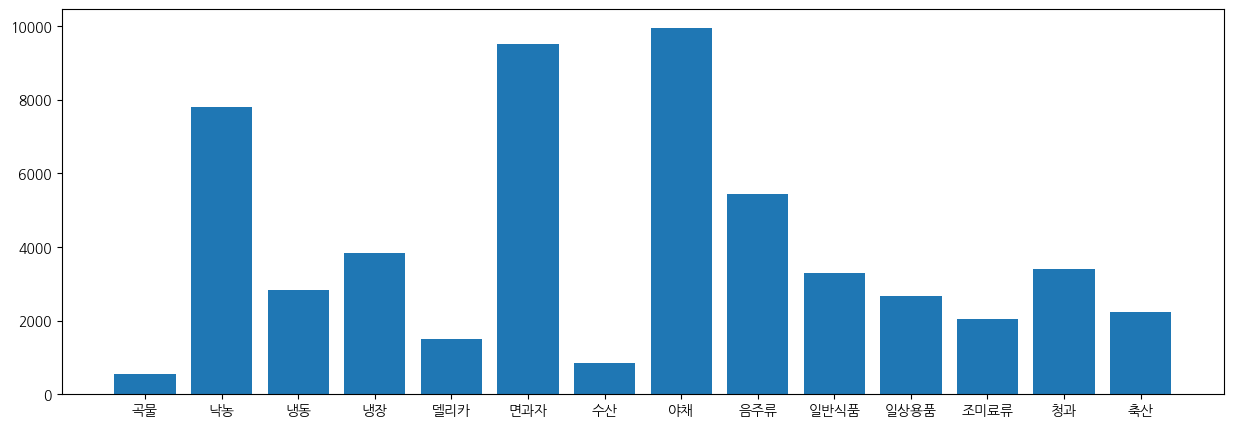

In [24]:
ratio=df.groupby(['상품대분류명'])['상품중분류명'].count()
ratio.reset_index()
plt.figure(figsize=(15,5))
plt.bar(ratio.index,ratio.values)

In [26]:
sales2=df.groupby(['상품대분류명','상품중분류명'])['상품중분류명'].value_counts()
sales2

상품대분류명  상품중분류명
곡물      양곡         236
        잡곡         307
낙농      냉장음료       925
        발효유       2127
        우유        4248
                  ... 
축산      국내산우육      397
        기타축산        27
        수입돈육        58
        수입우육       303
        양념육        150
Name: count, Length: 77, dtype: int64

In [96]:
sales1.values

array([29999380, 29963230, 29282690, 28752101, 23390374, 19525440,
       18235970, 18171620, 17824010, 13186310, 12000770,  9811690,
        4624340,  4571182])

In [60]:
from matplotlib.ticker import FuncFormatter

중분류 제품 매출 10위 이내에 야채는 계란만 포함되고 제품들의 단가도 낮지만, 상품대분류별 매출을 보았을 때 1위인 이유는 야채에 해당하는 품목수 자체가 많기 때문이다.

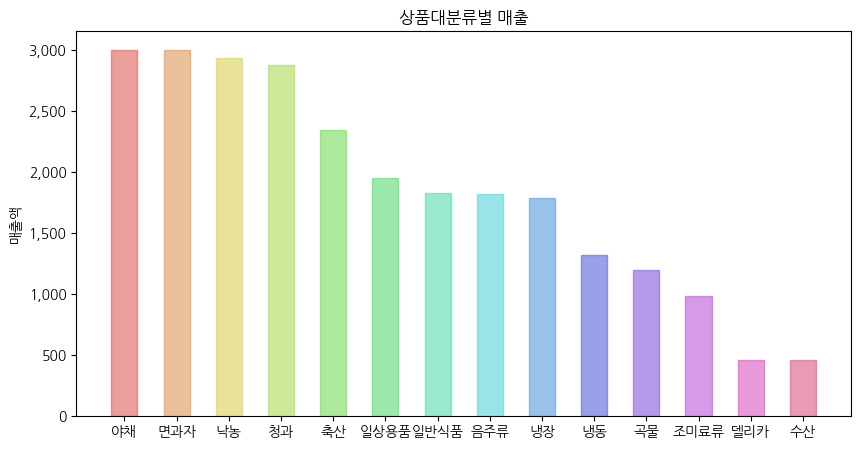

In [61]:
plt.figure(figsize=(10,5))
colors = sns.color_palette('hls',len(sales1.values)) ## 색상 지정
plt.bar(sales1.index,sales1.values,color=colors,edgecolor=colors,alpha=0.6,width=0.5)
plt.title('상품대분류별 매출')
plt.ylabel('매출액')
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{int(x/10000):,}')
)

# 상품중분류 월별 매출 추이 시각화


1.   구매일자 월 추출 후 파생변수 생성
2.   월별 / 매출별로 groupby
3. 시각화




In [85]:
df['거래월']=pd.to_datetime(df['거래일자'].astype(str),format='%Y%m%d').dt.month

In [125]:
sa1=df.groupby(['상품대분류명','거래월'])['구매금액'].sum()
sa1

상품대분류명  거래월
곡물      7       3375960
        8       4460190
        9       4164620
낙농      7       9729450
        8       9622410
        9       9930830
냉동      7       5250770
        8       4428240
        9       3507300
냉장      7       5839320
        8       6399300
        9       5585390
델리카     7       1537440
        8       1563140
        9       1523760
면과자     7       9910960
        8       9885530
        9      10166740
수산      7       1469630
        8       1600770
        9       1500782
야채      7       9344989
        8      10554398
        9      10099993
음주류     7       5920180
        8       5694500
        9       6556940
일반식품    7       5858920
        8       6233580
        9       6143470
일상용품    7       6183630
        8       6921600
        9       6420210
조미료류    7       2961270
        8       3203330
        9       3647090
청과      7      10998569
        8       8648195
        9       9105337
축산      7       8417163
        8       7718526
        9       7254685
Name: 구매금액, dtype: int64